# Notebook 13 — Interpretability and Error Analysis

## Purpose
I explain what the model has learned using feature importances, permutation
importances, and SHAP values.  I also analyse what the model gets wrong.

## Why this matters
A model that is accurate but unexplainable is not useful for business decisions.
This notebook translates model behaviour into actionable insights.

## Outputs
`reports/figures/shap_summary.png`, `reports/figures/partial_dependence.png`,
`reports/tables/error_analysis.csv`


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
from sklearn.metrics import accuracy_score

sys.path.insert(0, str(Path('..').resolve()))
from src.config import load_config
from src.paths import Paths
from src.visualization import plot_feature_importance, save_fig
from src.utils import save_table

cfg   = load_config()
paths = Paths(cfg)
FEAT  = cfg['modeling']['feature_cols_review']

test  = pd.read_parquet(paths.processed / 'test.parquet')
test_rv = test.dropna(subset=['review_score'] + FEAT)
X_te = test_rv[FEAT].fillna(0).values
y_te = test_rv['review_score'].astype(int).values

rf = joblib.load(paths.models / 'rf_review_model.joblib')
y_pred = rf.predict(X_te)
print("Model and test data loaded.")


Model and test data loaded.


  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\reports\figures\feature_importance_gini.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\paper_or_report\figures\feature_importance_gini.png


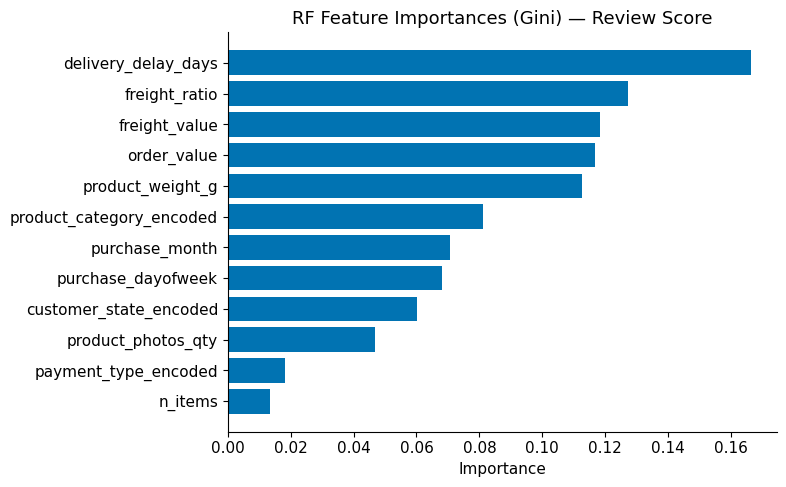

Top 5 features by Gini importance:
  delivery_delay_days                 0.1663
  freight_ratio                       0.1274
  freight_value                       0.1183
  order_value                         0.1169
  product_weight_g                    0.1126


In [2]:
# 1. Feature importances (Gini)
importances = rf.feature_importances_
fig = plot_feature_importance(
    FEAT, importances,
    title='RF Feature Importances (Gini) — Review Score',
    save_name='feature_importance_gini',
    reports_dir=str(paths.reports_figs),
    paper_dir=str(paths.paper_figs),
)
plt.show()
plt.close()

print("Top 5 features by Gini importance:")
top5 = sorted(zip(FEAT, importances), key=lambda x: x[1], reverse=True)[:5]
for name, imp in top5:
    print(f"  {name:<35} {imp:.4f}")


  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\reports\figures\feature_importance_permutation.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\paper_or_report\figures\feature_importance_permutation.png


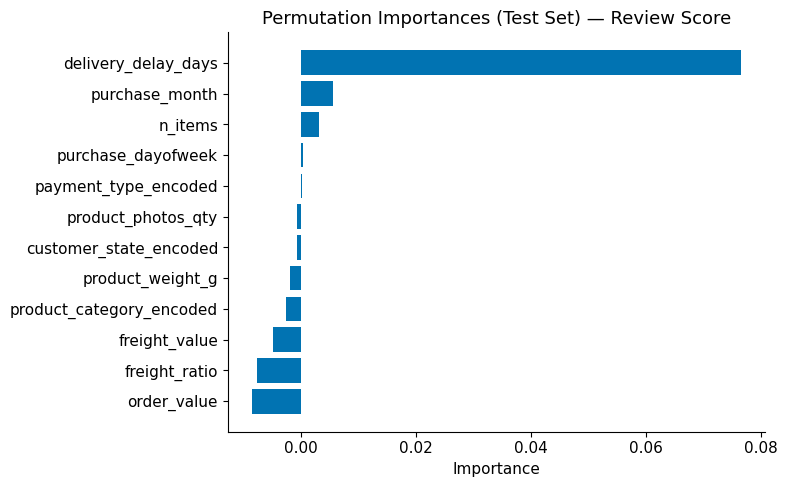

Permutation importance computed.


In [3]:
# 2. Permutation importance (model-agnostic)
from sklearn.inspection import permutation_importance
perm = permutation_importance(rf, X_te, y_te, n_repeats=10,
                              random_state=42, n_jobs=-1)
perm_means = perm.importances_mean
fig = plot_feature_importance(
    FEAT, perm_means,
    title='Permutation Importances (Test Set) — Review Score',
    save_name='feature_importance_permutation',
    reports_dir=str(paths.reports_figs),
    paper_dir=str(paths.paper_figs),
)
plt.show()
plt.close()
print("Permutation importance computed.")


Computing SHAP values (may take 1-2 minutes)...
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\reports\figures\shap_summary.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\paper_or_report\figures\shap_summary.png


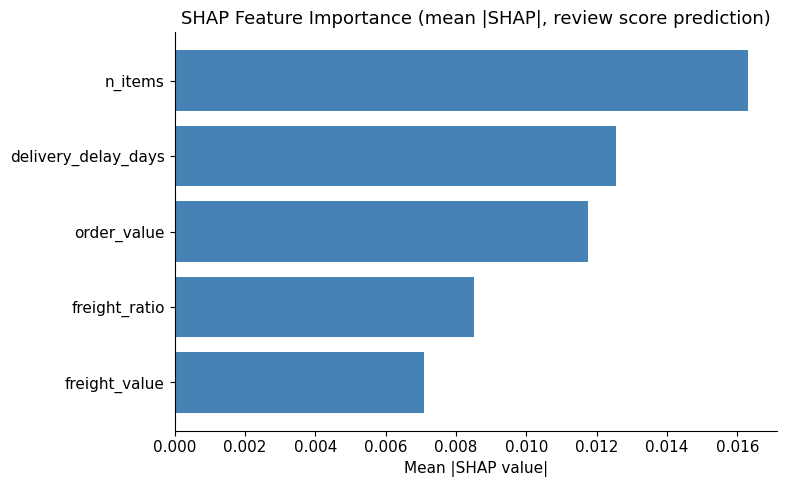

SHAP values computed and saved.


In [4]:
# 3. SHAP values (TreeSHAP — fast for RF)
print("Computing SHAP values (may take 1-2 minutes)...")
# Use a sample for speed
sample_size = min(2000, len(X_te))
rng = np.random.default_rng(42)
idx = rng.choice(len(X_te), sample_size, replace=False)
X_sample = X_te[idx]

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

# shap_values is a list of arrays (one per class)
# For summary plot, use the mean absolute SHAP across classes
shap_abs_mean = np.abs(np.array(shap_values)).mean(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
# Plot mean |SHAP| per feature
mean_shap = shap_abs_mean.mean(axis=0)
order = np.argsort(mean_shap)[-15:]
ax.barh([FEAT[i] for i in order], mean_shap[order], color='steelblue')
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("SHAP Feature Importance (mean |SHAP|, review score prediction)")
plt.tight_layout()
save_fig(fig, 'shap_summary',
         reports_dir=str(paths.reports_figs),
         paper_dir=str(paths.paper_figs))
plt.show()
plt.close()
print("SHAP values computed and saved.")


In [5]:
# 4. Error analysis — where does the model fail?
errors = pd.DataFrame({
    'true':      y_te,
    'predicted': y_pred,
    'error':     y_te - y_pred,
})
errors['abs_error'] = errors['error'].abs()
errors['correct'] = (errors['true'] == errors['predicted']).astype(int)

print("=== Error Analysis ===")
print("Accuracy per true score:")
for score in sorted(errors['true'].unique()):
    mask = errors['true'] == score
    acc = errors.loc[mask, 'correct'].mean()
    n = mask.sum()
    print(f"  Review {score}: accuracy = {acc:.3f}  (n={n:,})")


=== Error Analysis ===
Accuracy per true score:
  Review 1: accuracy = 0.478  (n=5,344)
  Review 2: accuracy = 0.017  (n=1,566)
  Review 3: accuracy = 0.065  (n=4,184)
  Review 4: accuracy = 0.139  (n=10,004)
  Review 5: accuracy = 0.788  (n=30,779)


In [6]:
# Errors by product category
test_rv_copy = test_rv.copy().reset_index(drop=True)
test_rv_copy['predicted_review'] = y_pred
test_rv_copy['correct'] = (test_rv_copy['review_score'] == test_rv_copy['predicted_review']).astype(int)

if 'product_category_english' in test_rv_copy.columns:
    cat_errors = (
        test_rv_copy.groupby('product_category_english')
        .agg(n=('order_id','count'), accuracy=('correct','mean'))
        .query('n >= 20')
        .sort_values('accuracy')
        .head(10)
        .reset_index()
    )
    print("\nCategories with lowest prediction accuracy:")
    print(cat_errors.to_string(index=False))
    save_table(cat_errors, 'error_by_category',
               reports_dir=str(paths.reports_tabs),
               paper_dir=str(paths.paper_tabs))
print("\nNotebook 13 complete.")



Categories with lowest prediction accuracy:
product_category_english    n  accuracy
        office_furniture  624  0.375000
   arts_and_craftmanship   21  0.380952
     diapers_and_hygiene   23  0.434783
  signaling_and_security  105  0.438095
  tablets_printing_image   20  0.450000
       furniture_bedroom   52  0.461538
          bed_bath_table 4750  0.480842
   furniture_living_room  206  0.490291
               telephony 2094  0.497135
                     art  157  0.503185
  Saved table: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\reports\tables\error_by_category.csv
  Saved table: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\paper_or_report\tables\error_by_category.csv

Notebook 13 complete.
